In [2]:
import pandas as pd
merged = pd.read_csv('data/MSFT_processed_data.csv')

In [3]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler


sentiment_map = {'positive': 1, 'neutral': 0, 'mixed': 0, 'negative': -1}
merged['Sentiment_Score'] = merged['Sentiment'].map(sentiment_map).fillna(0)
merged['Decayed_Sentiment'] = merged['Sentiment_Score'] / np.log1p(merged['News_Age_Minutes'] + 1)

features = [
    'Open', 'High', 'Low', 'Close', 'Volume', 
    'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'RSI_14', 
    'kalman_close', 'kalman_diff', 'Decayed_Sentiment'
]


merged['Target'] = (merged['Close'].shift(-1) > merged['Open'].shift(-1)).astype(int)
merged_clean = merged.dropna(subset=features + ['Target']).copy()

def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(merged_clean[features].values, merged_clean['Target'].values, 10)

train_size = int(len(X_seq) * 0.7)
val_size = int(len(X_seq) * 0.2)

X_train, y_train = X_seq[:train_size], y_seq[:train_size]
X_val, y_val = X_seq[train_size:train_size+val_size], y_seq[train_size:train_size+val_size]
X_test, y_test = X_seq[train_size+val_size:], y_seq[train_size+val_size:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, len(features))).reshape(X_train.shape)
X_val = scaler.transform(X_val.reshape(-1, len(features))).reshape(X_val.shape)
X_test = scaler.transform(X_test.reshape(-1, len(features))).reshape(X_test.shape)

train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)), batch_size=64, shuffle=False)
val_loader = DataLoader(TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val)), batch_size=64, shuffle=False)

C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Training on cuda for up to 50 epochs...
Epoch [1/50] | Train Loss: 0.6774 | Val Loss: 0.6651 | Val Acc: 0.5977
Epoch [2/50] | Train Loss: 0.6623 | Val Loss: 0.6620 | Val Acc: 0.6063
Epoch [3/50] | Train Loss: 0.6583 | Val Loss: 0.6602 | Val Acc: 0.6086
Epoch [4/50] | Train Loss: 0.6553 | Val Loss: 0.6581 | Val Acc: 0.6092
Epoch [5/50] | Train Loss: 0.6536 | Val Loss: 0.6553 | Val Acc: 0.6172
Epoch [6/50] | Train Loss: 0.6514 | Val Loss: 0.6549 | Val Acc: 0.6158
Epoch [7/50] | Train Loss: 0.6507 | Val Loss: 0.6548 | Val Acc: 0.6184
Epoch [8/50] | Train Loss: 0.6495 | Val Loss: 0.6540 | Val Acc: 0.6181
Epoch [9/50] | Train Loss: 0.6490 | Val Loss: 0.6541 | Val Acc: 0.6184
Epoch [10/50] | Train Loss: 0.6491 | Val Loss: 0.6551 | Val Acc: 0.6165
Epoch [11/50] | Train Loss: 0.6480 | Val Loss: 0.6543 | Val Acc: 0.6178
Epoch [12/50] | Train Loss: 0.6488 | Val Loss: 0.6554 | Val Acc: 0.6134
Epoch [13/50] | Train Loss: 0.6481 | Val Loss: 0.6566 | Val Acc: 0.6142
Epoch [14/50] | Train Loss: 0.647

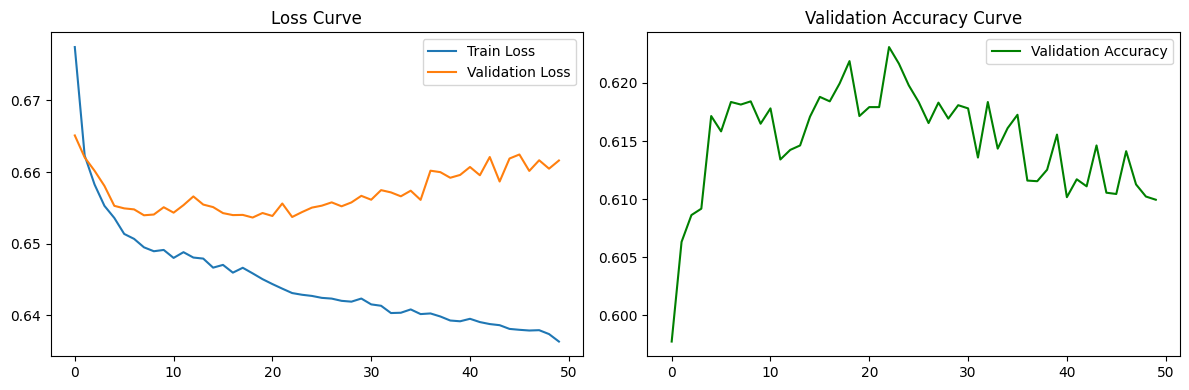

In [4]:
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch
import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def squash(x):
    s_sq_norm = torch.sum(x**2, dim=-1, keepdim=True)
    return (s_sq_norm / (1 + s_sq_norm)) * (x / torch.sqrt(s_sq_norm + 1e-9))

class CapsuleLayer(nn.Module):
    def __init__(self, num_capsules, num_route_nodes, in_channels, out_channels):
        super().__init__()
        self.W = nn.Parameter(torch.randn(num_capsules, num_route_nodes, in_channels, out_channels))
    def forward(self, x):
        x = x[:, None, :, :, None]
        u_hat = torch.matmul(self.W[None, ...].transpose(-1, -2), x).squeeze(-1)
        b_ij = torch.zeros(u_hat.size(0), 8, 10).to(x.device)
        for i in range(3):
            c_ij = F.softmax(b_ij, dim=1)
            v_j = squash((c_ij[:, :, :, None] * u_hat).sum(dim=2))
            if i < 2: b_ij = b_ij + (u_hat * v_j[:, :, None, :]).sum(dim=-1)
        return v_j

class HybridCapsNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.conv = nn.Conv1d(input_dim, 64, kernel_size=3, padding=1)
        self.caps = CapsuleLayer(8, 10, 64, 16)
        # Added a tiny bit of dropout to prevent overfitting
        self.lstm = nn.LSTM(16, 32, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(32, 2)
        
    def forward(self, x):
        x = F.relu(self.conv(x.transpose(1, 2))).transpose(1, 2)
        v_j = self.caps(x)
        _, (h_n, _) = self.lstm(v_j)
        return F.softmax(self.fc(h_n[-1]), dim=1)

model = HybridCapsNet(len(features)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}


EPOCHS = 50
PATIENCE = 50
best_val_loss = float('inf')
patience_counter = 0
best_model_weights = None

print(f"Training on {device} for up to {EPOCHS} epochs...")

for epoch in range(EPOCHS):
   
    model.train()
    total_train_loss = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

  
    model.eval()
    total_val_loss = 0
    correct_preds = 0
    total_samples = 0
    
    with torch.no_grad():
        for v_data, v_target in val_loader:
            v_data, v_target = v_data.to(device), v_target.to(device)
            
            v_output = model(v_data)
            v_loss = criterion(v_output, v_target)
            total_val_loss += v_loss.item()
            
    
            predictions = torch.argmax(v_output, dim=1)
            correct_preds += (predictions == v_target).sum().item()
            total_samples += v_target.size(0)
            
    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = correct_preds / total_samples
    
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f}")

  
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
       
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1
        
    if patience_counter >= PATIENCE:
        print(f"\n[🛑] Early stopping triggered at epoch {epoch+1}! Validation loss hasn't improved in {PATIENCE} epochs.")
        break

if best_model_weights:
    model.load_state_dict(best_model_weights)
    print("\n[✅] Best model weights restored!")


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], color='green', label='Validation Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

model.eval()
with torch.no_grad():
    probs = model(torch.FloatTensor(X_test).to(device)).cpu().numpy()[:, 1]
    y_pred = (probs > 0.50).astype(int)

print("\n" + "="*50)
print("             STATISTICAL PERFORMANCE")
print("="*50)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Down/Flat (0)', 'Up (1)']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


             STATISTICAL PERFORMANCE
Test Accuracy: 62.38%

Classification Report:
               precision    recall  f1-score   support

Down/Flat (0)       0.61      0.68      0.64      4573
       Up (1)       0.64      0.57      0.60      4513

     accuracy                           0.62      9086
    macro avg       0.62      0.62      0.62      9086
 weighted avg       0.62      0.62      0.62      9086


Confusion Matrix:
[[3101 1472]
 [1946 2567]]



             FINANCIAL PERFORMANCE
Initial Capital:         $10,000.00
Net Profit/Loss:         $9,444.03
Final Account Capital:   $19,444.03
Total ROI:               94.44%


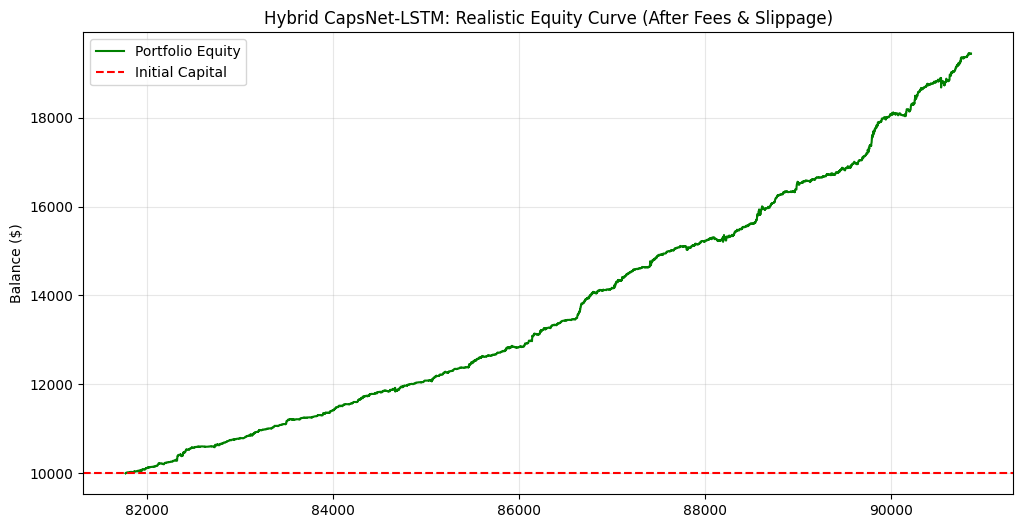

In [8]:

df_test = merged_clean.iloc[-len(probs):].copy()
df_test['Prob_Up'] = probs
df_test['Signal'] = (df_test['Prob_Up'] > 0.55).astype(int)

df_test['Entry_Price'] = df_test['Open'].shift(-1)
df_test['Exit_Price'] = df_test['Close'].shift(-1)
df_test = df_test.dropna(subset=['Entry_Price', 'Exit_Price']).copy()

INITIAL_CAPITAL = 10000.0
FEE_PER_SHARE = 0.009 
current_capital = INITIAL_CAPITAL
capital_history = []

for idx, row in df_test.iterrows():
    if row['Signal'] == 1:
        shares = np.floor(current_capital / row['Entry_Price'])
        gross_pnl = (row['Exit_Price'] - row['Entry_Price']) * shares
        fees = shares * FEE_PER_SHARE
        current_capital += (gross_pnl - fees)
    capital_history.append(current_capital)

df_test['Account_Balance'] = capital_history
profit = current_capital - INITIAL_CAPITAL

print("\n" + "="*50)
print("             FINANCIAL PERFORMANCE")
print("="*50)
print(f"Initial Capital:         ${INITIAL_CAPITAL:,.2f}")
print(f"Net Profit/Loss:         ${profit:,.2f}")
print(f"Final Account Capital:   ${current_capital:,.2f}")
print(f"Total ROI:               {(profit/INITIAL_CAPITAL)*100:.2f}%")
print("="*50)

plt.figure(figsize=(12, 6))
plt.plot(df_test.index, df_test['Account_Balance'], color='green', label='Portfolio Equity')
plt.axhline(INITIAL_CAPITAL, color='red', linestyle='--', label='Initial Capital')
plt.title('Hybrid CapsNet-LSTM: Realistic Equity Curve (After Fees & Slippage)')
plt.ylabel('Balance ($)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()